In [148]:
import sys; sys.path.insert(0, '..')
from pathlib import Path
import pandas as pd
import numpy as np, sqlite3
from src.config import DATA_RAW, DATA_PROCESSED
from src.db import load_table
import seaborn as sns


DB = '/Users/admin/Desktop/carbon-portfolio-project-v2/data/carbon.db'
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
print("root on path:", ROOT)

root on path: /Users/admin/Desktop/carbon-portfolio-project-v2


In [187]:
# %% auto-reload edited src modules (so src/*.py edits take effect without kernel restart)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [188]:
with sqlite3.connect(DB, timeout = 30) as con:
    con.executescript((ROOT / 'sql' / 'schema.sql').read_text())


## Section 1: Retrieving Fundamental Data from S&P Capital IQ Pro

In [4]:
# ── Section 0: export identifiers for manual S&P CIQ revenue pull ─────────────
with sqlite3.connect(DB, timeout=30) as con:
    mcl = pd.read_sql("""
        SELECT company_id, isin, ticker, universe
        FROM master_company_list
    """, con)

print(mcl.head())

     company_id          isin ticker universe
0  AT000000STR1  AT000000STR1    STR      ETS
1  IE00BYTBXV33  IE00BYTBXV33    RYA      ETS
2  IE00B010DT83  IE00B010DT83    CCR      ETS
3  IE0004927939  IE0004927939    KRX      ETS
4  IE0004906560  IE0004906560    KRZ      ETS


In [6]:
# real ISINs for the CIQ ISIN search

have_isin = mcl.loc[mcl['isin'].notna(), 'isin'].drop_duplicates().sort_values()
no_isin   = mcl.loc[mcl['isin'].isna(), ['company_id', 'ticker', 'universe']]

print(f"companies total     : {len(mcl):,}")
print(f"  with ISIN         : {have_isin.nunique():,}  -> CIQ ISIN pull")
print(f"  ticker-only (no ISIN): {len(no_isin):,}  -> need ticker/other lookup")
print(mcl.groupby('universe')['isin'].apply(lambda s: s.notna().sum()).to_string())

companies total     : 8,288
  with ISIN         : 8,233  -> CIQ ISIN pull
  ticker-only (no ISIN): 55  -> need ticker/other lookup
universe
ETS     300
EU     7933


In [7]:
# write one ISIN per line
isin_path = DATA_PROCESSED / 'ciq_revenue_isins.txt'
with open(isin_path, 'w') as f:
    f.write('\n'.join(have_isin))
print(f"\nwrote {have_isin.nunique():,} ISINs -> {isin_path}")

# stash the ticker-only names so they aren't lost from the revenue universe
no_isin.to_csv(DATA_PROCESSED / 'ciq_revenue_no_isin.csv', index=False)


wrote 8,233 ISINs -> /Users/admin/Desktop/carbon-portfolio-project-v2/notebooks/../data/processed/ciq_revenue_isins.txt


### Cleaning CIQ fundamental data

In [16]:
from functools import reduce

CIQ = DATA_RAW / 'ciq_fundamentals'          # adjust to wherever the 24 files live

In [15]:
def read_ciq(path, feature, numeric=True):
    raw = pd.read_excel(path, header=None, dtype=object)

    # get the columns period columns and filter only these columns:
    prow = next(i for i in range(8) if raw.iloc[i].astype(str).str.match(r'F[YQ]\d').any())
    periods = raw.iloc[prow]

    # get the columns:
    nmeta = next(j for j,v in enumerate(periods) if isinstance(v,str) and v[:2] in ('FY','FQ'))
    cols = list(raw.iloc[prow-1, :nmeta]) + list(periods[nmeta:])

    # 
    df = raw.iloc[prow+1:].copy(); df.columns = cols
    df = df[df['SP_ENTITY_ID'].notna()]

    fy = [c for c in df.columns if isinstance(c,str) and c.startswith('FY')]
    long = df.melt(id_vars=['SP_ENTITY_ID'],
                   value_vars=fy,
                   var_name='period',
                   value_name=feature)
    
    long['year'] = long['period'].str[2:].astype(int)
    long[feature] = long[feature].replace('NA', np.nan)
    if numeric: long[feature] = pd.to_numeric(long[feature], errors='coerce')
    return long[['SP_ENTITY_ID','year',feature]]

FEATURES = {                                    # €000 for monetary items
    'ciq_total_revenue.xlsx':'revenue', 'ciq_capital_expenditure.xlsx':'capex',
    'ciq_cash_and_equivalents.xlsx':'cash', 'ciq_cash_from_ops.xlsx':'cfo',
    'ciq_cash_short_term_investment.xlsx':'cash_sti', 'ciq_common_dividends_per_share.xlsx':'dps',
    'ciq_common_shares_outstanding.xlsx':'shares_out', 'ciq_earnings_from_cont_ops.xlsx':'earn_cont_ops',
    'ciq_ebidta.xlsx':'ebitda', 'ciq_ebit.xlsx':'ebit', 'ciq_gross_profit.xlsx':'gross_profit',
    'ciq_interest_expense.xlsx':'interest_expense', 'ciq_net_income.xlsx':'net_income',
    'ciq_net_income_to_common.xlsx':'ni_to_common', 'ciq_r&d_expense.xlsx':'rnd',
    'ciq_repurchase_of_common_stock.xlsx':'repurchase_common', 'ciq_total_asset.xlsx':'total_assets',
    'ciq_total_common_equity.xlsx':'total_common_equity', 'ciq_total_current_asset.xlsx':'total_current_assets',
    'ciq_total_debt.xlsx':'total_debt', 'ciq_total_liability.xlsx':'total_liabilities',
}
SPECIAL = {'ciq_financial_filing_date.xlsx':'filing_date',
           'ciq_annual_reported_currency.xlsx':'reported_currency'}

# reduce-merge all numeric features on (entity, year)
frames = [read_ciq(CIQ/f, name) for f,name in FEATURES.items()] # list comprehension of long form of all fundamental dataframes

NameError: name 'reduce' is not defined

In [52]:
# Create panel CIQ dataframe and merge with non-numeric columns:
panel = reduce(lambda l,r: l.merge(r, on=['SP_ENTITY_ID','year'], how='outer'), frames)

# non-numeric attributes
for f,name in SPECIAL.items():
    panel = panel.merge(read_ciq(CIQ/f, name, numeric=False), on=['SP_ENTITY_ID','year'], how='left')
panel['filing_date'] = pd.to_datetime(panel['filing_date'], errors='coerce')


In [ ]:
# metadata once (from revenue file), + map ISIN -> your company_id
meta = pd.read_excel(CIQ/'ciq_total_revenue.xlsx', header=None, dtype=object, skiprows=6)
meta.columns = ['SP_ENTITY_NAME','SP_ENTITY_ID','SP_COMPANY_NAME','SP_TICKER','SP_EXCHANGE','SP_ISIN','SP_NACE_Code'] + [f'v{i}' for i in range(meta.shape[1]-7)]
meta = meta.loc[meta['SP_ENTITY_ID'].notna(), ['SP_ENTITY_ID','SP_ISIN','SP_NACE_Code', 'SP_ENTITY_NAME']]

In [53]:
import sqlite3
DB = '/Users/admin/Desktop/carbon-portfolio-project-v2/data/carbon.db'
with sqlite3.connect(DB, timeout=30) as con:
    xwalk = pd.read_sql("SELECT company_id, isin FROM master_company_list WHERE isin IS NOT NULL", con)

panel = panel.merge(meta, on='SP_ENTITY_ID', how='left') \
             .merge(xwalk, left_on='SP_ISIN', right_on='isin', how='left')

print(f"panel shape       : {panel.shape}")
print(f"entities          : {panel['SP_ENTITY_ID'].nunique():,}")
print(f"mapped company_id : {panel['company_id'].notna().sum():,} rows / "
      f"{panel.loc[panel['company_id'].notna(),'SP_ENTITY_ID'].nunique():,} entities")
print(f"unmapped ISINs    : {panel.loc[panel['company_id'].isna(),'SP_ISIN'].nunique():,}")
print(panel[['company_id','year','revenue','ebitda','total_assets','filing_date','reported_currency']].head())

panel shape       : (107324, 30)
entities          : 7,666
mapped company_id : 106,302 rows / 7,593 entities
unmapped ISINs    : 11
     company_id  year       revenue        ebitda  total_assets filing_date  \
0  IE00BLP1HW54  2012  8.979338e+06  1.741075e+06   23122106.70  2015-02-24   
1  IE00BLP1HW54  2013  8.920917e+06  1.715793e+06   21966763.65  2016-02-22   
2  IE00BLP1HW54  2014  9.097679e+06  1.936847e+06   24596137.80  2017-02-23   
3  IE00BLP1HW54  2015  1.055489e+07  1.893912e+06   24752522.25  2018-02-20   
4  IE00BLP1HW54  2016  8.526934e+06  1.769400e+06   25212389.50  2019-02-19   

  reported_currency  
0               USD  
1               USD  
2               USD  
3               USD  
4               USD  


### Load Fundamentals 

In [90]:
with sqlite3.connect(DB, timeout=30) as con:
    con.execute("DROP TABLE IF EXISTS fundamentals")
    con.executescript(open('../sql/schema.sql').read())   # re-run whole schema; IF NOT EXISTS protects the rest
    con.commit()
    print(pd.read_sql("PRAGMA table_info(fundamentals)", con)[['name','type']].to_string(index=False))

                name    type
          company_id    TEXT
                year INTEGER
             revenue    REAL
               capex    REAL
                cash    REAL
            cash_sti    REAL
                 cfo    REAL
                 dps    REAL
          shares_out    REAL
       earn_cont_ops    REAL
              ebitda    REAL
                ebit    REAL
        gross_profit    REAL
    interest_expense    REAL
          net_income    REAL
        ni_to_common    REAL
                 rnd    REAL
   repurchase_common    REAL
        total_assets    REAL
 total_common_equity    REAL
total_current_assets    REAL
          total_debt    REAL
   total_liabilities    REAL
   reported_currency    TEXT
         filing_date    TEXT
        sp_entity_id    TEXT


In [91]:
fund = panel[panel['company_id'].notna()].rename(columns={'SP_ENTITY_ID':'sp_entity_id'})

In [132]:
# one row per (company_id, year): keep the entity carrying the most data.
meta_cols = ['company_id','year','sp_entity_id','reported_currency','filing_date',
             'SP_ISIN','SP_ENTITY_NAME','SP_NACE_Code','isin']
val_cols  = [c for c in fund.columns if c not in meta_cols]

fund_one = (fund.assign(_n=fund[val_cols].notna().sum(axis=1))
                .sort_values('_n', ascending=False)
                .drop_duplicates(['company_id','year'], keep='first')
                .drop(columns='_n')
                .sort_values(['company_id','year'])
                .reset_index(drop=True))

assert fund_one.duplicated(['company_id','year']).sum() == 0
print(f"rows: {len(fund_one):,}   companies: {fund_one['company_id'].nunique():,}")

rows: 103,852   companies: 7,418


In [134]:
with sqlite3.connect(DB, timeout=30) as con:
    load_table(con, fund_one, 'fundamentals')
    n    = con.execute("SELECT COUNT(*) FROM fundamentals").fetchone()[0]
    orph = con.execute("""SELECT COUNT(*) FROM fundamentals f
        LEFT JOIN master_company_list m ON m.company_id=f.company_id
        WHERE m.company_id IS NULL""").fetchone()[0]
print(f"loaded {n:,}   orphans {orph}")

  fundamentals           103,852 rows
loaded 103,852   orphans 0


## Section 2: carbon features

Carbon intensity (Scope 1 emissions ÷ revenue) is the core carbon signal, measuring emissions efficiency per unit of business activity. Emissions come from company_emissions (ETS registry + Trucost); revenue from fundamentals, matched on (company_id, year).

Four data-quality steps were applied before computing the ratio, each guarding against a specific distortion:

- Negative revenue -> NaN. 922 rows had negative "revenue," concentrated in financials (NACE 64–66), where CIQ forces bank/insurer income statements into an industrial revenue template. Revenue cannot be negative, so these were nulled in the fundamentals table.
- Financial sectors excluded from intensity. All NACE 64–66 firms are dropped from the intensity signal, even with positive revenue, a bank's figure is not comparable to an industrial's sales, so the ratio is meaningless. Their Scope 1 is negligible, so no carbon information is lost. They remain in the universe for non-carbon features.
- Revenue floor of €1M: to establish denominator consistency, preventing carbon intensity from inflating artificially (e.g., some revenue dropped due to errors to be)
- winsorization: clips the extreme tails so any residual denominator noise below the floor can't set the values. This matters specifically because Section 3 cuts terciles — and one outlier can drag a tercile boundary, misclassifying firms. Winsorizing makes the tier cut-points robust. Raw intensity is kept alongside for interpretability; only the tiering uses the winsorized version.

Profiling confirmed unit consistency across sources: ETS median intensity (0.065) sits ~5× above Trucost (0.013), consistent with ETS being heavy industry, and both distributions fall within one order of magnitude; ruling out a tonnes-vs-kilotonnes or €-vs-€000 mismatch.

In [146]:
from src.profiling import profile_numeric, plot_dist

In [135]:
with sqlite3.connect(DB, timeout=30) as con:
    emis = pd.read_sql("SELECT company_id, year, scope1_emissions, source FROM company_emissions", con)
    rev  = pd.read_sql("SELECT company_id, year, revenue FROM fundamentals", con)

In [137]:
carbon = emis.merge(rev, on=['company_id','year'], how='left')

In [138]:

# intensity = tonnes CO2 / EUR'000 revenue  (revenue<=0 or NaN -> undefined)
carbon['carbon_intensity'] = np.where(carbon['revenue'] > 0,
                                      carbon['scope1_emissions'] / carbon['revenue'],
                                      np.nan)
carbon['log_intensity'] = np.log(carbon['carbon_intensity'].where(carbon['carbon_intensity'] > 0))

In [145]:
print(f"emission rows           : {len(carbon):,}")
print(f"  with revenue matched  : {carbon['revenue'].notna().sum():,}")
print(f"  intensity computable  : {carbon['carbon_intensity'].notna().sum():,}")
print(carbon.groupby('source')['carbon_intensity'].apply(lambda s: s.notna().sum()))
print(carbon['carbon_intensity'].describe())

emission rows           : 12,487
  with revenue matched  : 11,920
  intensity computable  : 11,914
source
ets_registry    3174
trucost         8740
Name: carbon_intensity, dtype: int64
count    11914.000000
mean         6.213912
std        616.592705
min          0.000000
25%          0.003929
50%          0.013336
75%          0.045734
max      67288.157881
Name: carbon_intensity, dtype: float64


                                      n  miss%  zero  neg           min            p1           p50           p99           max  skew  oom
scope1_emissions [ets_registry]  3273.0    0.0  17.0  0.0  0.000000e+00     59.440000  1.495000e+05  2.910982e+07  7.338516e+07   5.4  5.3
scope1_emissions [trucost]       9214.0    0.0  23.0  0.0  0.000000e+00      8.318853  8.171382e+03  3.519587e+06  8.103959e+07  20.0  5.4
revenue [ets_registry]           3273.0    2.9   0.0  3.0 -2.670119e+06  19295.628035  4.560650e+06  1.718644e+08  3.635888e+08   4.8  3.9
revenue [trucost]                9214.0    5.1   0.0  3.0 -7.139000e+06   3254.423382  9.094177e+05  5.161665e+07  2.741200e+08   8.4  4.2
carbon_intensity [ets_registry]  3273.0    3.0  17.0  0.0  0.000000e+00      0.000002  5.758970e-02  1.363624e+01  6.728816e+04  56.3  6.2
carbon_intensity [trucost]       9214.0    5.1  23.0  0.0  0.000000e+00      0.000075  1.091570e-02  1.977641e+00  3.890617e+01  31.1  4.3


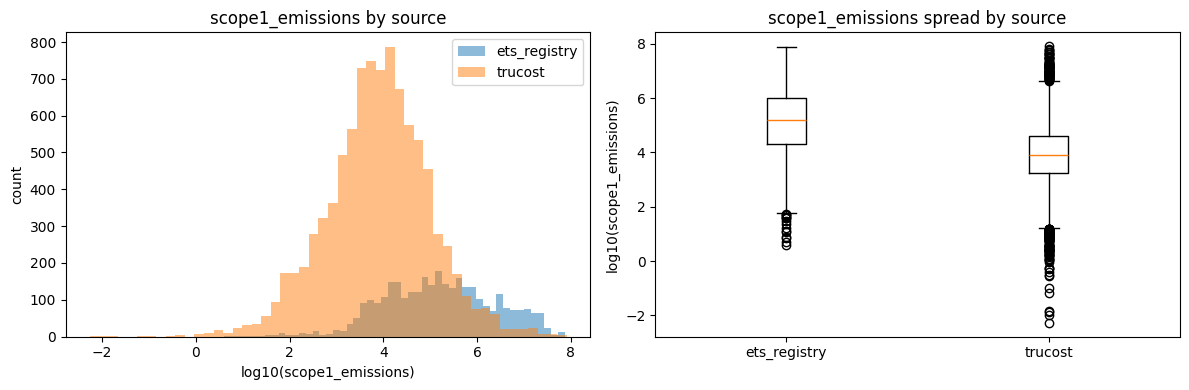

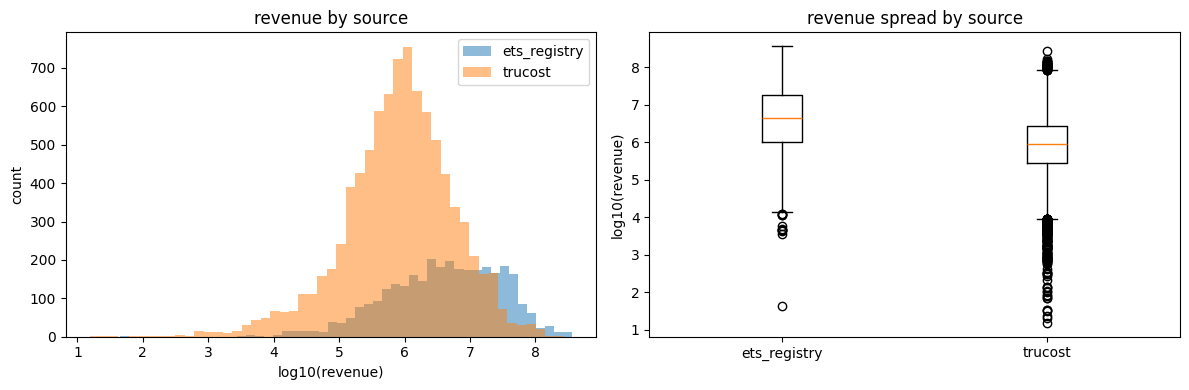

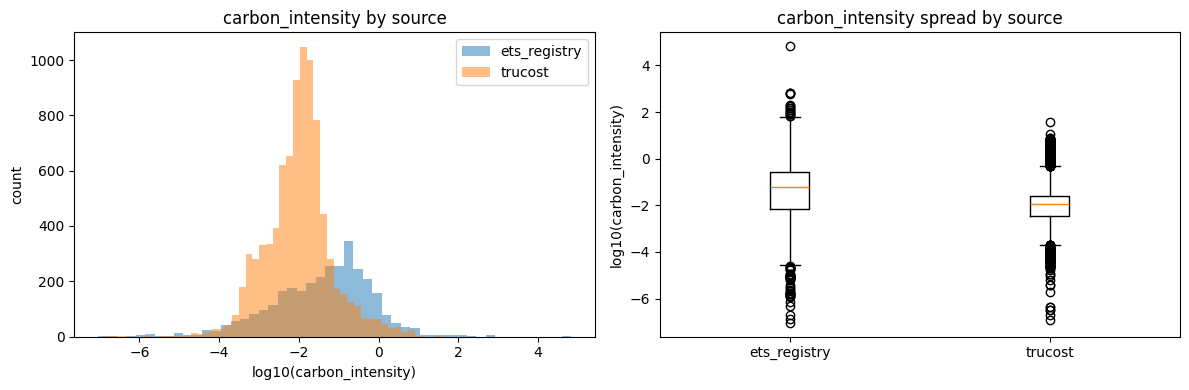

  company_id  year       source  scope1_emissions     revenue  carbon_intensity
GB00BYX5K988  2016 ets_registry         2965495.0   44.071574      67288.157881
GB00BYX5K988  2013 ets_registry         2971466.0 4447.557926        668.111815
GB00BYX5K988  2014 ets_registry         2986114.0 4477.088884        666.976707
GB00BYX5K988  2012 ets_registry         2980893.0 4648.091626        641.315456
GB00BYX5K988  2015 ets_registry         2899421.0 4773.220010        607.435022


In [150]:
print(profile_numeric(carbon, ['scope1_emissions','revenue','carbon_intensity'], by='source').to_string())
for c in ['scope1_emissions','revenue','carbon_intensity']:
    plot_dist(carbon, c)

# is the 67k max a tiny-denominator artifact or a real/unit problem?
print(carbon.nlargest(5,'carbon_intensity')
      [['company_id','year','source','scope1_emissions','revenue','carbon_intensity']].to_string(index=False))

In [ ]:
# check if negative revenues correspond to banking sector:
with sqlite3.connect(DB, timeout=30) as con:
    neg = pd.read_sql("SELECT company_id, year, revenue FROM fundamentals WHERE revenue < 0", con)

nace = panel[['company_id','SP_NACE_Code']].drop_duplicates('company_id')
neg = neg.merge(nace, on='company_id', how='left')
neg['nace2'] = neg['SP_NACE_Code'].str.extract(r'(\d{2})')
print(neg['nace2'].value_counts().head(10).to_string())


In [157]:
# 1. negative revenue -> NaN in the stored table (universal)
with sqlite3.connect(DB, timeout=30) as con:
    n = con.execute("UPDATE fundamentals SET revenue = NULL WHERE revenue < 0").rowcount
    con.commit()
print(f"negatives nulled: {n}")

negatives nulled: 922


In [156]:
# 2. flag financials for exclusion from intensity (carbon frame only, not the table)
carbon = carbon.merge(nace[['company_id','SP_NACE_Code']], on='company_id', how='left')
carbon['nace2'] = carbon['SP_NACE_Code'].str.extract(r'(\d{2})')
carbon['is_financial'] = carbon['nace2'].isin(['64','65','66'])

nace2
64    567
66     75
70     22
07     17
68     13
82     12
65      5
21      5
09      5
52      5


In [160]:
# intensity: financials excluded, revenue floored, then winsorized within source
REV_FLOOR = 1000
ok = (carbon['revenue'] > REV_FLOOR) & (~carbon['is_financial']) # flooring
carbon['carbon_intensity'] = np.where(ok, carbon['scope1_emissions']/carbon['revenue'], np.nan)
carbon['intensity_w'] = (carbon.groupby('source')['carbon_intensity']
                                .transform(lambda s: s.clip(s.quantile(.01), s.quantile(.99)))) # winsorization:

print(f"financials excluded from intensity : {carbon['is_financial'].sum():,}")
print(f"intensity computable               : {carbon['carbon_intensity'].notna().sum():,}")
print(carbon.groupby('source')['intensity_w'].describe()[['min','50%','max']])
print("rows lost to floor  :",
      ((carbon['revenue']>0)&(carbon['revenue']<=REV_FLOOR)&(~carbon['is_financial'])).sum())

financials excluded from intensity : 1,274
intensity computable               : 10,627
                   min       50%        max
source                                     
ets_registry  0.000014  0.064597  12.986846
trucost       0.000115  0.013098   2.467187
rows lost to floor  : 45


In [162]:
carbon['company_id'].nunique()

1306

### Section 3: NACE-neutral carbon tiers

In [181]:
carbon['nace1'] = carbon['SP_NACE_Code'].str.extract(r'(\d)')   # 1-digit section

def tercile_within(g):
    if g.notna().sum() < 6:
        return pd.Series(np.nan, index=g.index)
    return pd.qcut(g.rank(method='first'), 3, labels=['low','medium','high'])

carbon['carbon_tier'] = pd.Series(pd.NA, index=carbon.index, dtype='object')
for src in ['ets_registry', 'trucost']:
    m = (carbon['source']==src) & carbon['intensity_w'].notna()
    sub = carbon[m].copy()

    # group by year and nace1:
    sub['t'] = sub.groupby(['year','nace1'])['intensity_w'].transform(tercile_within)
    prefix = 'ets' if src=='ets_registry' else 'non_ets'
    carbon.loc[sub.index, 'carbon_tier'] = prefix + '_' + sub['t'].astype(str)
    carbon.loc[sub.index[sub['t'].isna()], 'carbon_tier'] = prefix + '_untiered'

print(carbon['carbon_tier'].value_counts(dropna=False).to_string())

carbon_tier
non_ets_high        2557
non_ets_low         2516
non_ets_medium      2473
<NA>                1860
ets_high             999
ets_low              974
ets_medium           944
ets_untiered         128
non_ets_untiered      36


In [183]:
# dealing with remaining untiered rows (categorise according within year only, not within sector)

for src in ['ets_registry', 'trucost']:
    prefix = 'ets' if src=='ets_registry' else 'non_ets'
    m = (carbon['carbon_tier'] == f'{prefix}_untiered')
    sub = carbon[m].copy()

    # group by year only:
    sub['t'] = sub.groupby('year')['intensity_w'].transform(tercile_within)   # year-only
    carbon.loc[sub.index, 'carbon_tier'] = prefix + '_' + sub['t'].astype(str)
    # anything STILL untiered (tiny year cohorts) -> leave as _untiered
    carbon.loc[sub.index[sub['t'].isna()], 'carbon_tier'] = f'{prefix}_untiered'

print(carbon['carbon_tier'].value_counts(dropna=False).to_string())

carbon_tier
non_ets_high        2562
non_ets_low         2521
non_ets_medium      2478
<NA>                1860
ets_high            1046
ets_low             1017
ets_medium           982
non_ets_untiered      21


In [184]:
na = carbon[carbon['carbon_tier'].isna()]
print("financials      :", na['is_financial'].sum())
print("no revenue match:", na['revenue'].isna().sum())
print("below floor     :", ((na['revenue']>0)&(na['revenue']<=1000)).sum())

financials      : 1274
no revenue match: 567
below floor     : 45


In [190]:
# Populate NACE to master_company_list on database:
nace_src = (panel[['company_id','SP_NACE_Code']]
            .dropna(subset=['company_id','SP_NACE_Code'])
            .drop_duplicates('company_id'))          # one NACE per company


In [191]:
with sqlite3.connect(DB, timeout=30) as con:
    # add column if missing (ALTER is safe, non-destructive)
    cols = [r[1] for r in con.execute("PRAGMA table_info(master_company_list)")]
    if 'nace_code' not in cols:
        con.execute("ALTER TABLE master_company_list ADD COLUMN nace_code TEXT")
    con.executemany("UPDATE master_company_list SET nace_code=? WHERE company_id=?",
                    nace_src[['SP_NACE_Code','company_id']].itertuples(index=False, name=None))
    con.commit()
    filled = con.execute("SELECT COUNT(*) FROM master_company_list WHERE nace_code IS NOT NULL").fetchone()[0]
    tot    = con.execute("SELECT COUNT(*) FROM master_company_list").fetchone()[0]
print(f"nace_code filled: {filled:,}/{tot:,}")

nace_code filled: 6,806/8,288


In [193]:
with sqlite3.connect(DB, timeout=30) as con:
    print(pd.read_sql("""SELECT universe, COUNT(*) n
        FROM master_company_list WHERE nace_code IS NULL GROUP BY universe""", con))

  universe     n
0      ETS     5
1       EU  1477
